# Feature Analysis for Stock Return Prediction

This notebook analyzes the effectiveness of the generated features for predicting the **percentage change (Return)** of Taiwan stocks.

We will use:
1.  **Correlation Heatmap**: To see which features are linearly correlated with the target.
2.  **Feature Importance (Random Forest)**: To see which features are most useful for a non-linear tree-based model.

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os

# Add src to path
sys.path.insert(0, os.path.abspath('src'))

from Feature_Engineering_V2 import prepare_training_data_v2

## 1. Load Data with Return as Target

We set `target_col='Return'` to predict the percentage change.

In [9]:
STOCK_ID = "2330" # TSMC

# Prepare data: Target is Next Day's Return
df = prepare_training_data_v2(STOCK_ID, path= "data/twstock.db")

if df is None or df.empty:
    print("Error: No data found. Please check if the database exists and has data for this stock.")
else:
    print(f"Data Shape: {df.shape}")
    display(df.head())

df.columns

Data Shape: (858, 79)


,Open_Gap,High_Chg,Low_Chg,Close_Chg,Vol_Chg,Bias_5,Bias_10,Bias_20,Bias_60,NATR,...,TSM_ADR_Close_Chg_Lag_2,TSM_ADR_Close_Chg_Lag_3,TSM_ADR_Close_Chg_Lag_4,TSM_ADR_Close_Chg_Lag_5,TWII_Index_Close_Chg_Lag_1,TWII_Index_Close_Chg_Lag_2,TWII_Index_Close_Chg_Lag_3,TWII_Index_Close_Chg_Lag_4,TWII_Index_Close_Chg_Lag_5,Future_Return
Date,,,,,,,,,,,,,,,,,,,,,
2021-05-04,0.000000,0.010204,-0.010204,0.005102,-0.035650,-0.012036,-0.013026,-0.021280,-0.030512,0.017162,...,-0.004680,-0.013276,-0.002057,0.024275,-0.019600,-0.000049,-0.001612,0.001344,0.015723,-0.010152
2021-05-05,0.005076,0.005076,-0.010152,-0.010152,-0.273599,-0.013823,-0.020265,-0.029851,-0.039093,0.016972,...,-0.026532,-0.004680,-0.013276,-0.002057,-0.016756,-0.019600,-0.000049,-0.001612,0.001344,0.003419
2021-05-06,0.008547,0.008547,-0.008547,0.003419,0.050276,-0.005422,-0.016091,-0.024674,-0.035016,0.016671,...,-0.005003,-0.026532,-0.004680,-0.013276,-0.005335,-0.016756,-0.019600,-0.000049,-0.001612,0.020443
2021-05-07,0.011925,0.022147,0.003407,0.020443,-0.086243,0.015254,0.002678,-0.003576,-0.014857,0.015979,...,0.000173,-0.005003,-0.026532,-0.004680,0.008960,-0.005335,-0.016756,-0.019600,-0.000049,-0.016694
2021-05-10,-0.005008,-0.003339,-0.018364,-0.016694,-0.272180,-0.002033,-0.011911,-0.018497,-0.030984,0.016493,...,0.014041,0.000173,-0.005003,-0.026532,0.017102,0.008960,-0.005335,-0.016756,-0.019600,-0.030560


Index(['Open_Gap', 'High_Chg', 'Low_Chg', 'Close_Chg', 'Vol_Chg', 'Bias_5',
       'Bias_10', 'Bias_20', 'Bias_60', 'NATR', 'RSI', 'MACD_Hist_Norm',
       'Daily_Range_Pct', 'Close_Loc', 'SOX_Index_Close_Chg',
       'SP500_Index_Close_Chg', 'TSM_ADR_Close_Chg', 'TWII_Index_Close_Chg',
       'Close_Chg_Lag_1', 'Close_Chg_Lag_2', 'Close_Chg_Lag_3',
       'Close_Chg_Lag_4', 'Close_Chg_Lag_5', 'Vol_Chg_Lag_1', 'Vol_Chg_Lag_2',
       'Vol_Chg_Lag_3', 'Vol_Chg_Lag_4', 'Vol_Chg_Lag_5', 'RSI_Lag_1',
       'RSI_Lag_2', 'RSI_Lag_3', 'RSI_Lag_4', 'RSI_Lag_5',
       'MACD_Hist_Norm_Lag_1', 'MACD_Hist_Norm_Lag_2', 'MACD_Hist_Norm_Lag_3',
       'MACD_Hist_Norm_Lag_4', 'MACD_Hist_Norm_Lag_5', 'Bias_5_Lag_1',
       'Bias_5_Lag_2', 'Bias_5_Lag_3', 'Bias_5_Lag_4', 'Bias_5_Lag_5',
       'Bias_20_Lag_1', 'Bias_20_Lag_2', 'Bias_20_Lag_3', 'Bias_20_Lag_4',
       'Bias_20_Lag_5', 'High_Chg_Lag_1', 'High_Chg_Lag_2', 'High_Chg_Lag_3',
       'High_Chg_Lag_4', 'High_Chg_Lag_5', 'Low_Chg_Lag_1', 'Low_

## 2. Correlation Analysis (Heatmap)

We calculate the correlation of all features with the `Target` (Next Day Return). 
Since there are many features (80+), we will plot the **Top 20 features** with the highest absolute correlation.

Top 20 Features by Correlation with Target:
TSM_ADR_Close_Chg             0.544684
SOX_Index_Close_Chg           0.536252
SP500_Index_Close_Chg         0.456221
Bias_5_Lag_4                  0.099024
TSM_ADR_Close_Chg_Lag_4       0.095922
TWII_Index_Close_Chg_Lag_4    0.093775
MACD_Hist_Norm_Lag_3          0.092736
High_Chg_Lag_4                0.091649
Vol_Chg_Lag_1                 0.088742
MACD_Hist_Norm_Lag_4          0.088433
MACD_Hist_Norm_Lag_2          0.087965
Bias_20_Lag_4                 0.087055
Close_Chg_Lag_4               0.085058
Close_Loc                    -0.081466
Bias_20_Lag_3                 0.077894
RSI_Lag_4                     0.074023
MACD_Hist_Norm_Lag_5          0.067715
MACD_Hist_Norm_Lag_1          0.066820
High_Chg_Lag_5                0.065705
Low_Chg_Lag_4                 0.064763
Name: Future_Return, dtype: float64


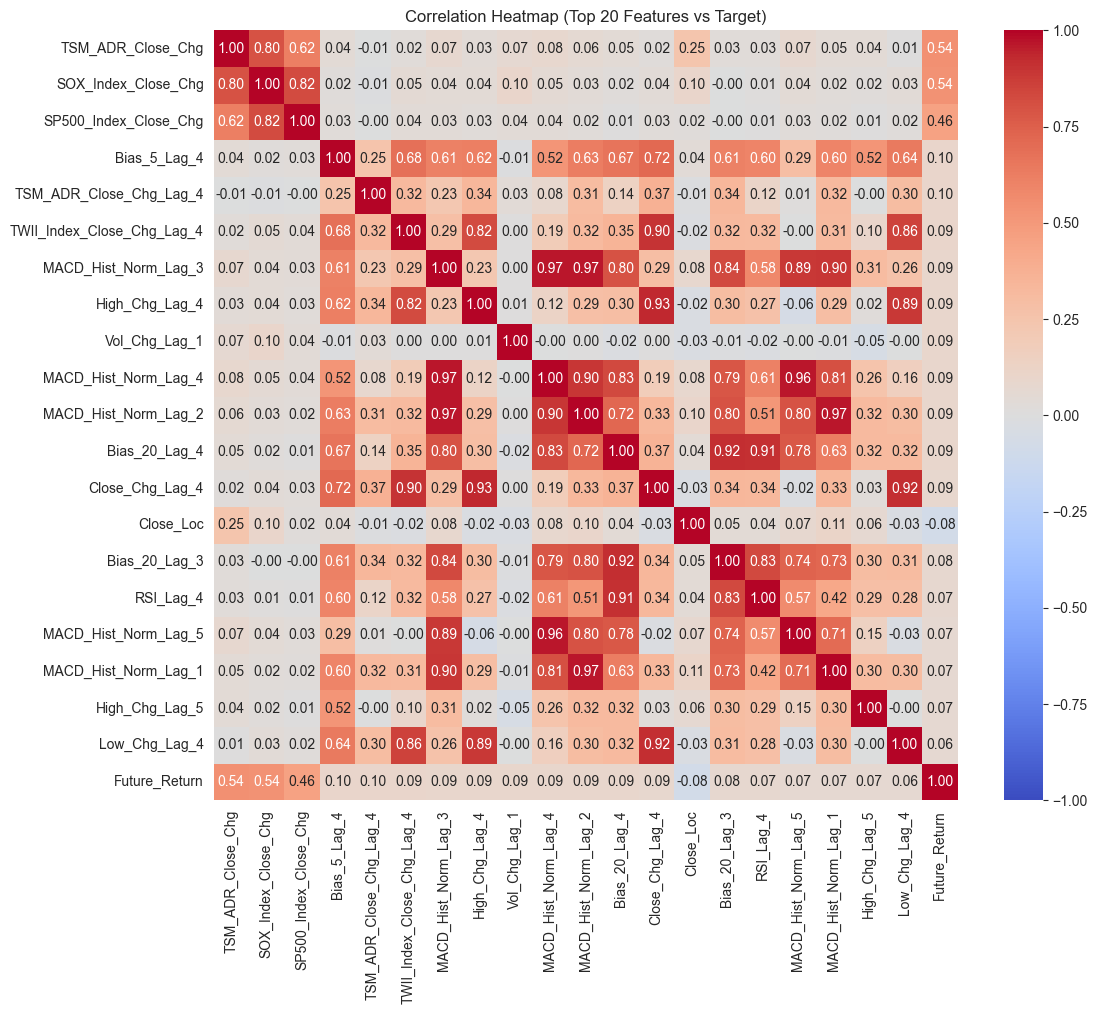

In [12]:
if df is not None and not df.empty:
    # Calculate correlation matrix
    corr_matrix = df.corr()

    # Get correlation with Target
    target_corr = corr_matrix['Future_Return'].drop('Future_Return') # Drop target itself

    # Sort by absolute correlation
    top_features = target_corr.abs().sort_values(ascending=False).head(20)
    top_features_names = top_features.index.tolist()

    print("Top 20 Features by Correlation with Target:")
    print(target_corr[top_features_names])

    # Plot Heatmap of these top features
    plt.figure(figsize=(12, 10))
    top_corr_matrix = df[top_features_names + ['Future_Return']].corr()
    sns.heatmap(top_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
    plt.title("Correlation Heatmap (Top 20 Features vs Target)")
    plt.show()

### Analysis of Correlation
- **High Correlation**: Indicates a strong linear relationship. If `Return_Lag_1` is high, it means momentum exists.
- **Low Correlation**: Doesn't mean the feature is useless! It might have a non-linear relationship captured by complex models.

## 3. Feature Importance (Random Forest)

Linear correlation misses non-linear patterns. A Random Forest model can tell us which features are actually used to split the data and reduce variance.

C:\Users\bc261\AppData\Local\Temp\ipykernel_43580\3693738185.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')


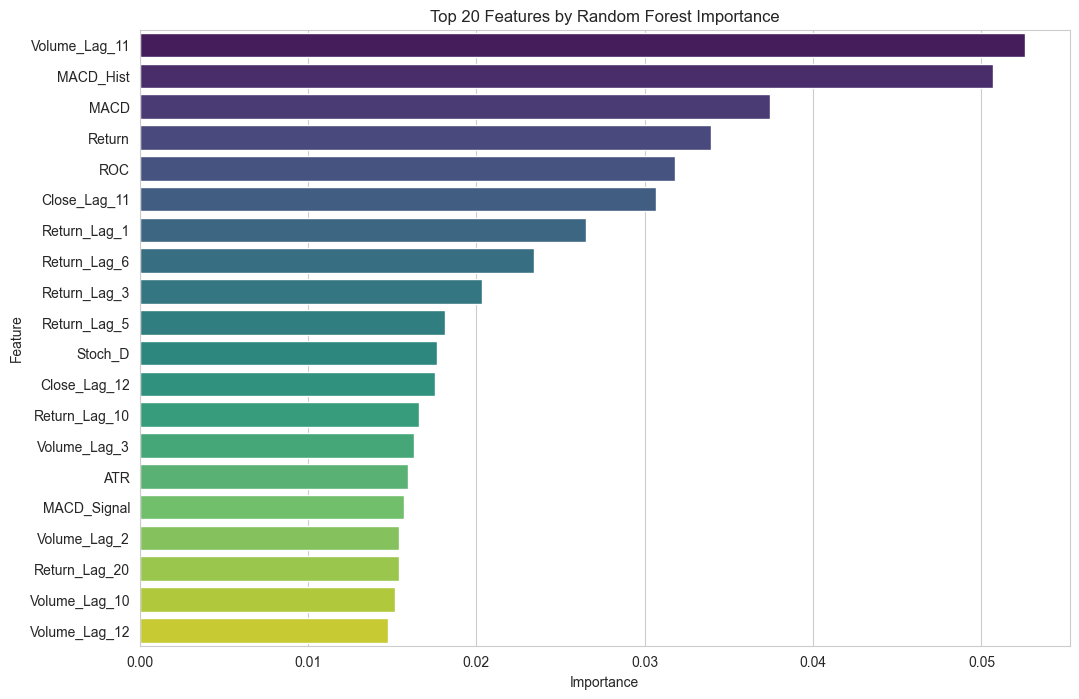

In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

if df is not None and not df.empty:
    # Prepare X and y
    X = df.drop(columns=['Target'])
    y = df['Target']

    # Split data (Time Series split: Train on past, Test on future)
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    # Train Random Forest
    rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)

    # Get Feature Importances
    importances = rf.feature_importances_
    feature_names = X.columns

    # Create DataFrame for plotting
    fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    fi_df = fi_df.sort_values(by='Importance', ascending=False).head(20)

    # Plot
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')
    plt.title("Top 20 Features by Random Forest Importance")
    plt.show()

## 4. Conclusion

By comparing the **Correlation Heatmap** and **Random Forest Importance**, we can identify the most robust features.

- Features that appear in **both** lists are likely very strong predictors.
- Features only in **Random Forest** list likely have complex, non-linear relationships with the price change.
- **Lag Features** (e.g., `Return_Lag_1`, `Volume_Lag_1`) often show high importance in time-series prediction.

## 5. Feature Documentation

Here is a detailed explanation of all the features generated by our `Feature_Engineering.py` script.

### A. Raw Data (5 Features)
These are the raw values from the stock market.
*   **Open, High, Low, Close**: Daily price data.
*   **Volume**: Number of shares traded.

### B. Trend Indicators (9 Features)
Used to identify the direction of the market trend.
*   **SMA_5, SMA_10, SMA_20, SMA_60**: Simple Moving Averages. Average price over the last N days.
    *   *Usage*: Identify support/resistance levels and trend direction.
*   **EMA_12, EMA_26**: Exponential Moving Averages. Give more weight to recent prices.
    *   *Usage*: More responsive to recent price changes than SMA.
*   **MACD**: Moving Average Convergence Divergence. `EMA_12 - EMA_26`.
*   **MACD_Signal**: 9-day EMA of MACD.
*   **MACD_Hist**: `MACD - MACD_Signal`.
    *   *Usage*: Identify momentum changes and potential buy/sell signals (crossovers).

### C. Momentum Indicators (5 Features)
Used to determine the strength of the price movement and overbought/oversold conditions.
*   **RSI (Relative Strength Index)**: Measures the speed and change of price movements (0-100).
    *   *Usage*: >70 Overbought (potential sell), <30 Oversold (potential buy).
*   **Stoch_K, Stoch_D (KD)**: Stochastic Oscillator. Compares closing price to price range over time.
    *   *Usage*: Similar to RSI, identifies turning points.
*   **ROC (Rate of Change)**: Percentage change in price over N days.
    *   *Usage*: Measures the velocity of price change.
*   **Williams %R**: Momentum indicator that measures overbought and oversold levels.
    *   *Usage*: Similar to Stochastic Oscillator.

### D. Volatility Indicators (4 Features)
Used to measure how much the price is fluctuating.
*   **BB_Upper, BB_Lower**: Bollinger Bands. `SMA_20 +/- 2 * StdDev`.
*   **BB_Width**: `(Upper - Lower) / SMA_20`.
    *   *Usage*: Measures volatility. Squeeze (low width) often precedes a breakout.
*   **ATR (Average True Range)**: Measures market volatility by decomposing the entire range of an asset price for that period.
    *   *Usage*: Often used for setting stop-loss levels.

### E. Volume Indicators (1 Feature)
*   **OBV (On-Balance Volume)**: Cumulative volume based on price direction.
    *   *Usage*: Confirms price trends. Divergence between price and OBV can signal reversals.

### F. Pattern Features (2 Features)
*   **Bullish_Alignment**: Boolean (0 or 1). True if `SMA_5 > SMA_10 > SMA_20 > SMA_60`.
    *   *Usage*: Strong signal of an established uptrend.
*   **MA_Entanglement**: `StdDev(SMAs) / Close`.
    *   *Usage*: Measures how close the moving averages are. Low values indicate "entanglement" (consolidation), often preceding a big move.

### G. Lag Features (60 Features)
Historical context for the model.
*   **Close_Lag_1...20**: Closing price 1 to 20 days ago.
*   **Volume_Lag_1...20**: Volume 1 to 20 days ago.
*   **Return_Lag_1...20**: Daily return 1 to 20 days ago.
    *   *Usage*: Allows the model to "see" the past price shape and momentum patterns.

In [22]:
import twstock as tw
import finlab as fl

['1101',
 '1102',
 '1103',
 '1104',
 '1108',
 '1109',
 '1110',
 '1201',
 '1203',
 '1210',
 '1213',
 '1215',
 '1216',
 '1217',
 '1218',
 '1219',
 '1220',
 '1225',
 '1227',
 '1229',
 '1231',
 '1232',
 '1233',
 '1234',
 '1235',
 '1236',
 '1256',
 '1301',
 '1303',
 '1304',
 '1305',
 '1307',
 '1308',
 '1309',
 '1310',
 '1312',
 '1313',
 '1314',
 '1315',
 '1316',
 '1319',
 '1321',
 '1323',
 '1324',
 '1325',
 '1326',
 '1337',
 '1338',
 '1339',
 '1340',
 '1341',
 '1342',
 '1402',
 '1409',
 '1410',
 '1413',
 '1414',
 '1416',
 '1417',
 '1418',
 '1419',
 '1423',
 '1432',
 '1434',
 '1435',
 '1436',
 '1437',
 '1438',
 '1439',
 '1440',
 '1441',
 '1442',
 '1443',
 '1444',
 '1445',
 '1446',
 '1447',
 '1449',
 '1451',
 '1452',
 '1453',
 '1454',
 '1455',
 '1456',
 '1457',
 '1459',
 '1460',
 '1463',
 '1464',
 '1465',
 '1466',
 '1467',
 '1468',
 '1470',
 '1471',
 '1472',
 '1473',
 '1474',
 '1475',
 '1476',
 '1477',
 '1503',
 '1504',
 '1506',
 '1512',
 '1513',
 '1514',
 '1515',
 '1516',
 '1517',
 '1519',
 